In [15]:
import pandas as pd
from sklearn.model_selection import train_test_split
from imblearn.under_sampling import RandomUnderSampler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import KFold
df = pd.read_csv('/content/sample_data/california_housing_train.csv')

In [2]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,-114.31,34.19,15.0,5612.0,1283.0,1015.0,472.0,1.4936,66900.0
1,-114.47,34.40,19.0,7650.0,1901.0,1129.0,463.0,1.8200,80100.0
2,-114.56,33.69,17.0,720.0,174.0,333.0,117.0,1.6509,85700.0
3,-114.57,33.64,14.0,1501.0,337.0,515.0,226.0,3.1917,73400.0
4,-114.57,33.57,20.0,1454.0,326.0,624.0,262.0,1.9250,65500.0


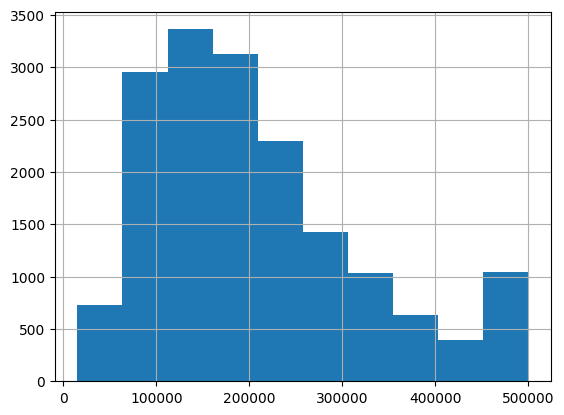

In [3]:
import matplotlib.pyplot as plt

df['median_house_value'].hist()
plt.show()

In [4]:
# create a new target variable for SMOTE
import numpy as np

# nice imbalanced data!
df['median_house_value'] = np.where(df['median_house_value'] < 380000, 1, 0)
df['median_house_value'].value_counts()

,count
median_house_value,
1,15304
0,1696


In [6]:
# Split data into train and test
X = df.drop('median_house_value', axis=1)
y = df['median_house_value']
validation_size = 0.20
seed = 123

# split!
X_train, X_test, Y_train, Y_test = train_test_split(X, y, test_size=validation_size, random_state=seed)
X_train.shape, X_test.shape, Y_train.shape, Y_test.shape

((13600, 8), (3400, 8), (13600,), (3400,))

In [7]:
# Check distribution of target variable
df['median_house_value'].value_counts()

,count
median_house_value,
500001.0,814
137500.0,95
162500.0,89
112500.0,85
187500.0,74
...,...
442000.0,1
328400.0,1
296300.0,1


In [11]:
# Majority Undersampling
undersample = RandomUnderSampler(sampling_strategy='majority')
X_train_under, Y_train_under = undersample.fit_resample(X_train, Y_train)
X_train_under.shape, Y_train_under.shape

((12971, 8), (12971,))

In [14]:
# Fit the model to X_train_under and Y_train_under
model = LogisticRegression()
model.fit(X_train_under, Y_train_under)

/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [18]:
predictions = model.predict(X_test)

In [21]:
#num_folds = 10
#kfold = KFold(n_splits=num_folds, random_state=seed, shuffle=True)
print(classification_report(predictions,Y_test))

              precision    recall  f1-score   support

     14999.0       0.00      0.00      0.00         0
     26900.0       0.00      0.00      0.00         0
     27500.0       0.00      0.00      0.00         0
     34200.0       0.00      0.00      0.00         0
     38800.0       0.00      0.00      0.00         0
     42500.0       0.00      0.00      0.00         0
     43000.0       0.00      0.00      0.00         0
     43600.0       0.00      0.00      0.00         0
     44400.0       0.00      0.00      0.00         0
     45000.0       0.00      0.00      0.00         0
     45600.0       0.00      0.00      0.00         0
     46300.0       0.00      0.00      0.00         0
     46700.0       0.00      0.00      0.00         0
     46900.0       0.00      0.00      0.00         0
     47500.0       0.00      0.00      0.00         0
     47700.0       0.00      0.00      0.00         0
     47800.0       0.00      0.00      0.00         0
     48100.0       0.00    

/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_